In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [2]:
try:
    df = pd.read_csv('cleaned_ott.csv')
except FileNotFoundError:
    print("Error")
    exit()

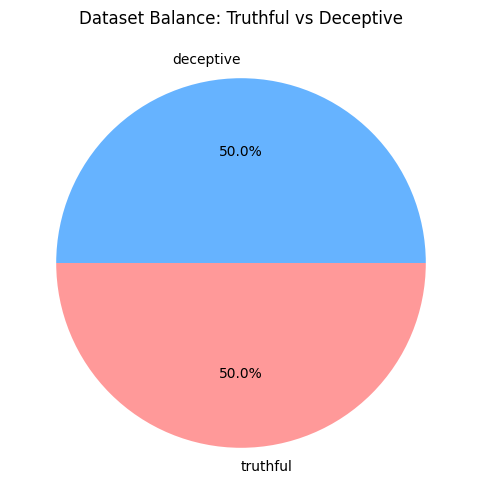

In [7]:
plt.figure(figsize=(6, 6))
df['label'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
plt.title('Dataset Balance: Truthful vs Deceptive')
plt.ylabel('')
plt.show()
plt.close()

In [8]:

df['word_count'] = df['review_text'].apply(lambda x: len(str(x).split()))
fraud_avg = df[df['label'] == 'deceptive']['word_count'].mean()
genuine_avg = df[df['label'] == 'truthful']['word_count'].mean()
overall_avg = df['word_count'].mean()

print("Fraud Average Review Length:", fraud_avg)
print("Genuine Average Review Length:", genuine_avg)
print("Overall Average Review Length:", overall_avg)

Fraud Average Review Length: 146.63625
Genuine Average Review Length: 150.91375
Overall Average Review Length: 148.775


Generating Word Clouds (this takes a moment)...


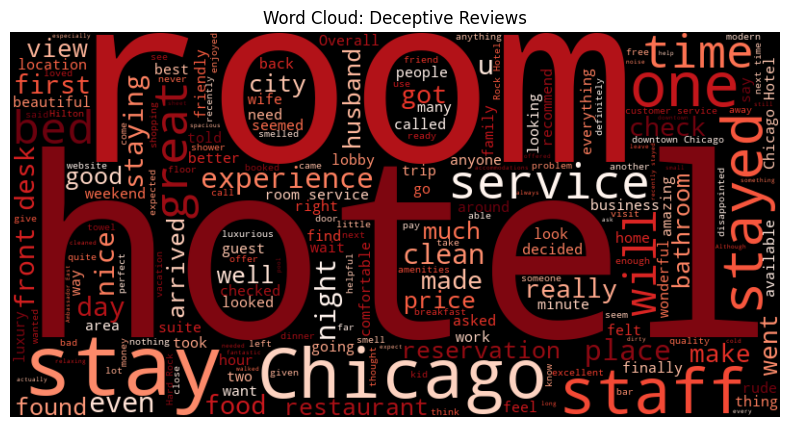

In [9]:
truthful_text = " ".join(df[df['label']=='truthful']['review_text'])
deceptive_text = " ".join(df[df['label']=='deceptive']['review_text'])

print("Generating Word Clouds (this takes a moment)...")
wc_deceptive = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(deceptive_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc_deceptive, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud: Deceptive Reviews')
plt.show()
plt.close()

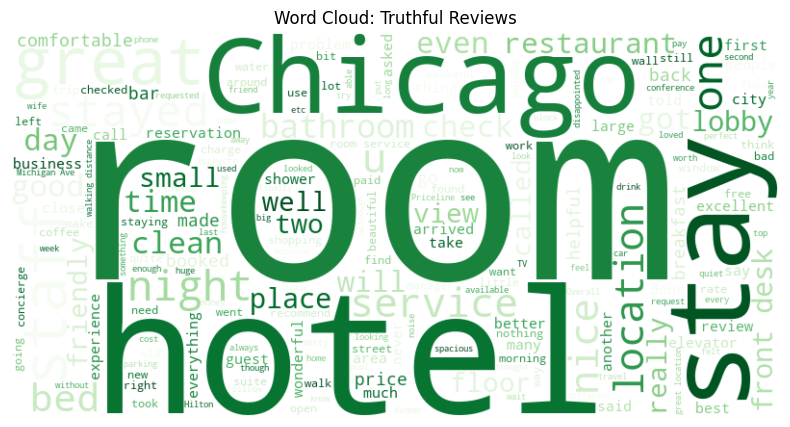

In [10]:

wc_truthful = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(truthful_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc_truthful, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud: Truthful Reviews')
plt.show()
plt.close()